# BrushCue Example: Vaporwave Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/vaporwave_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/vaporwave-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


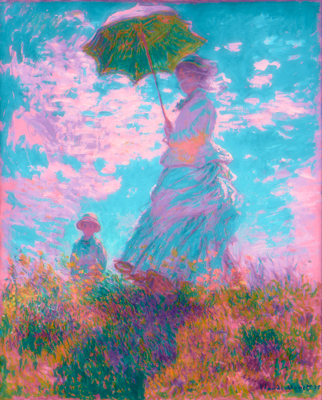

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
mapped = input_image.color_transformer_shader(
    "let c = length(input.yz);\nlet h = atan2(input.z, input.y);\nlet colorful = smoothstep(0.006, 0.035, c);\nlet cool = band(h, 3.6, 2.0);\nlet hue_goal = mix(-0.3, 3.35, cool);\nlet h2 = h + atan2(sin(hue_goal - h), cos(hue_goal - h)) * 0.75 * amount;\nlet c2 = mix(c, max(c * 1.25, 0.11), amount * colorful);\nlet t = clamp(input.x, 0.0, 1.0);\nvar ramp = mix(vec2<f32>(0.06, -0.13), vec2<f32>(0.08, -0.075), smoothstep(0.1, 0.55, t));\nramp = mix(ramp, vec2<f32>(0.04, 0.035), smoothstep(0.6, 1.0, t));\nlet shifted = vec2<f32>(c2 * cos(h2), c2 * sin(h2));\nlet ab = mix(shifted, ramp, (1.0 - colorful) * 0.7 * amount) + ramp * 0.18 * amount;\nlet l = mix(input.x, 0.12 + input.x * 0.86, amount);\nreturn vec4<f32>(l, ab.x, ab.y, input.w);",
    "fn band(h: f32, center: f32, width: f32) -> f32 {\n  let d = abs(atan2(sin(h - center), cos(h - center)));\n  return 1.0 - smoothstep(width * 0.5, width, d);\n}",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)
bounds = input_image.bounds()
split_px = (bounds.width() * 0.0015) * strength
split = mapped.spacial_effect_shader(
    "let min_position = image_bounds.xy + vec2<f32>(0.5);\nlet max_position = image_bounds.zw - vec2<f32>(0.5);\nlet r = sample(clamp(position + vec2<f32>(split_px, 0.0), min_position, max_position)).r;\nlet center = sample(position);\nlet b = sample(clamp(position - vec2<f32>(split_px, 0.0), min_position, max_position)).b;\nreturn vec4<f32>(r, center.g, b, center.a);",
    "",
    (split_px + 1.0),
    bc.Dictionary.create().add("split_px", split_px).add("image_bounds", bounds),
    bc.ColorRepresentation.srgb(),
)
glowed = split.bloom(0.55, (bounds.width() * 0.01), (0.35 * strength))
graph = glowed.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
